# Decay angle of the leading muon pair in a muon lepton jet

This study measures, for every muon-type lepton jet with at least two constituent muons,
the decay angle of its two leading muons in their own rest frame, and compares that angle
between simulated signal, simulated background and collision data across a set of control
and validation regions.

The notebook is a driver: all of the loading, normalisation and drawing lives in
`_mulj_lib.py` in this directory, and each figure comes from one function there.  The
configuration cell below is the only cell that needs to change when the inputs change --
the sample lists are read from whatever is present in the input directory.

Each section states what its figures show and what follows from them; section g collects the
caveats that apply to every reading of them, and section h states the verdict.

In [1]:
import os
import sys

# locate the study directory whether the notebook was started in it or from the repository root
_candidates = []
_walk = os.getcwd()
while True:
    _candidates.append(_walk)
    _candidates.append(os.path.join(_walk, "sidm", "studies", "mulj_decay_angle"))
    _parent = os.path.dirname(_walk)
    if _parent == _walk:
        break
    _walk = _parent
_study_dir = next(d for d in _candidates if os.path.exists(os.path.join(d, "_mulj_lib.py")))
sys.path.insert(0, _study_dir)

import _mulj_lib as lib

%matplotlib inline

## Configuration

`INPUT_DIR` points at a directory of merged, one-file-per-sample `.coffea` outputs.  It
accepts a local path or an EOS `root://` URL, in which case files are copied to a local
cache the first time they are read.

`LUMI_FB` is the integrated luminosity printed in the CMS label of figures that contain
data.  Leave it as `None` while running over a partial data set, so that no figure claims
a luminosity it does not have; set it to the processed luminosity once the full campaign
is in.

In [2]:
# ---------------------------------------------------------------------------------
# The only settings that change between a test run and the full campaign.
# ---------------------------------------------------------------------------------
# INPUT_DIR = "/uscms_data/d3/murtazas/mulj_smoke"          # reduced test inputs
INPUT_DIR = "/uscms_data/d3/murtazas/mulj_merged"     # merged campaign outputs
# INPUT_DIR = "root://cmseos.fnal.gov//store/group/lpcmetx/SIDM/coffea_outputs/murtazas/mulj_decay_angle"

LUMI_FB = 59.8                       # set to 59.8 for the full 2018 data set

M_ZD_VALUES = (0.25, 1.2, 5.0)       # dark-photon masses shown as separate columns
M_ZD_REFERENCE = 1.2                 # mass point used for the single-point figures
# ---------------------------------------------------------------------------------

lib.configure(input_dir=INPUT_DIR, lumi_fb=LUMI_FB)
lib.set_style(dpi=85)
print("input directory :", lib.INPUT_DIR)
print("figures written to:", lib.FIG_DIR)

input directory : /uscms_data/d3/murtazas/mulj_merged
figures written to: /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures


### What is in the input directory

Samples are classified by name: `4Mu_*` and `2Mu2E_*` are signal, `DoubleMuon_2018*` is
collision data, and anything else with a configured cross section is simulated background.
The table counts muon pairs, not events: one entry per muon lepton jet with at least two
muons.

In [3]:
print("signal    :", len(lib.signal_samples()), "samples")
print("data      :", len(lib.data_samples()), "samples")
print("background:", len(lib.background_samples()), "samples")
print()
_ = lib.inventory()

signal    : 66 samples
data      : 68 samples
background: 18 samples

group                                      1muLj       1muLj_cosmic_veto  1muLj_spread_cosAlpha_  test_VR_2mu2e_invDispl  test_VR_4mu_invDisplac
------------------------------------------------------------------------------------------------------------------------------------------------


data                                     8242639                 8177789                 1620742                    7403                    5040


background                               1775056                 1765809                 1126548                    6882                   20373
signal 4Mu m_Zd=0.25                        6837                    6921                    3757                     993                  621617
signal 4Mu m_Zd=1.2                       201327                  198147                  130549                    2037                 1092262
signal 4Mu m_Zd=5.0                       170957                  167516                  110843                    1875                 1121419
signal 2Mu2E m_Zd=0.25                     11247                   11229                    9293                  130696                      34


signal 2Mu2E m_Zd=1.2                      88969                   88295                   70135                  182358                     100
signal 2Mu2E m_Zd=5.0                      81841                   81173                   64320                  150350                      80


## a. Definitions and method

Every quantity below is computed per muon-type lepton jet, from the **two leading-transverse-momentum
constituent muons** of that lepton jet.  The constituent list mixes particle-flow muons and
displaced-standalone muons, and is sorted by transverse momentum inside each lepton jet; only lepton
jets holding at least two muons contribute, which is imposed explicitly rather than inherited from a
channel's muon-multiplicity cut.

* Each of the two muons is given a four-vector with the muon mass, 0.105658 GeV.
* The **pair** is the sum of those two four-vectors; its invariant mass is the pair mass shown
  throughout.
* **The boost.** The leading muon is boosted into the rest frame of the pair, and the decay angle
  is the angle between that boosted momentum and the direction of the pair in the laboratory.
  The absolute value of its cosine is stored, since swapping the two muons flips the sign.
* The **momentum ratio** is the sub-leading over the leading muon transverse momentum in the
  laboratory, in the range 0 to 1.
* Companion quantities recorded alongside the angle for each pair: lepton-jet transverse momentum
  and isolation, pair mass, angular separation of the two muons, the smaller and larger of their
  transverse impact parameters, the number of displaced-standalone muons among the two (0, 1 or 2),
  each muon's transverse momentum, and the lepton-jet-level impact-parameter spreads used by the
  cleaning cuts.

Every histogram axis for a given histogram is filled from the same jagged array, so a pair
contributes one entry to each axis of the same histogram.  The implementation is a single helper in
`sidm/definitions/hists.py`; the axis lambdas only pick fields off it, which is what keeps the axes
structurally identical.

### The two-leading-muon convention

A muon lepton jet can hold more than two muons.  This study always takes the two hardest, and makes
no attempt to pick the pair that best reconstructs a dark photon.  The consequence is that in a
lepton jet with three or more muons the "pair" need not be the true decay pair, and the angle is then
a property of the reconstructed object rather than of a decay.  The number of displaced-standalone
muons in the pair is recorded so that this population can be separated out.

### Regions

| region | what it selects |
| --- | --- |
| single lepton jet, no cleaning | events with exactly one muon-type lepton jet, no cleaning cuts applied; the largest and least biased fake sample |
| single lepton jet, cosmic veto | the same, with the cosmic-muon veto applied |
| single lepton jet, spread and angle vetoes | the same, with the lepton-jet impact-parameter spread cuts and the muon-pair opening-angle veto applied |
| 2mu2e inverted-displacement validation region | the two-lepton-jet selection with one muon and one electromagnetic lepton jet, with the displacement requirement inverted on every lepton jet |
| 4mu inverted-displacement validation region | the two-muon-lepton-jet selection with the displacement requirement inverted on every lepton jet |

The two validation regions are orthogonal to the signal region by construction: the signal region
requires every lepton jet to be displaced, and these require the exact negation.  In both of them the
muon lepton jet under study is prompt by construction, which is why the dependence of the angle on
displacement is measured in the uncut single-lepton-jet control region instead.

A muon lepton jet reconstructed from a dark-photon decay carries one internal degree of
freedom that the standard lepton-jet variables (pT, mass, dR, isolation, displacement) do
not use: where along the allowed kinematic band its two muons sit. In the rest frame of the
muon pair, a spin-1 dark photon decaying to muons follows dN/dcos(theta*) ~ 1 + alpha cos^2(theta*)
with alpha near 1 when m_Zd is well above the dimuon threshold (the transverse polarization a
vector boson inherits when it couples to light fermions); exactly at threshold the muons are
produced at rest in the pair frame and no decay direction exists to measure. A fake muon
lepton jet, meaning two muons that happen to be clustered together, has no reason to follow
this distribution. In the lab the accessible observables are |cos(theta*)| and the momentum
ratio r = pT_sub / pT_lead; for a collimated pair r = (1 - beta* cos(theta*)) / (1 + beta* cos(theta*)),
so the narrow band in the (|cos(theta*)|, r) plane is a kinematic identity shared by any
collimated pair, and the discriminating information is the position along the band, not the
band itself. This study measures that position for signal after the full selection, for
simulated backgrounds, and for fake-enriched data control regions, and asks two questions:
does the shape separate genuine from fake muon lepton jets, and is it correlated with the
variables the background estimate already uses.

## b. Signal reference

Generator-level and reconstructed angle for one dark-photon mass, and the plane of angle against
momentum ratio with the two-body-decay band drawn on it.  All lifetimes and mediator masses of the
mass point are summed; the angular distribution of a two-body decay does not depend on how far the
parent travelled before decaying, so the sum is legitimate and buys statistics.

The band is the ratio of laboratory momenta expected for a two-body decay of a fast parent,
(1 - beta* cos theta*) / (1 + beta* cos theta*), with beta* the muon speed in the pair rest frame
computed from the nominal dark-photon mass and the muon mass.

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/b1_gen_vs_reco.pdf


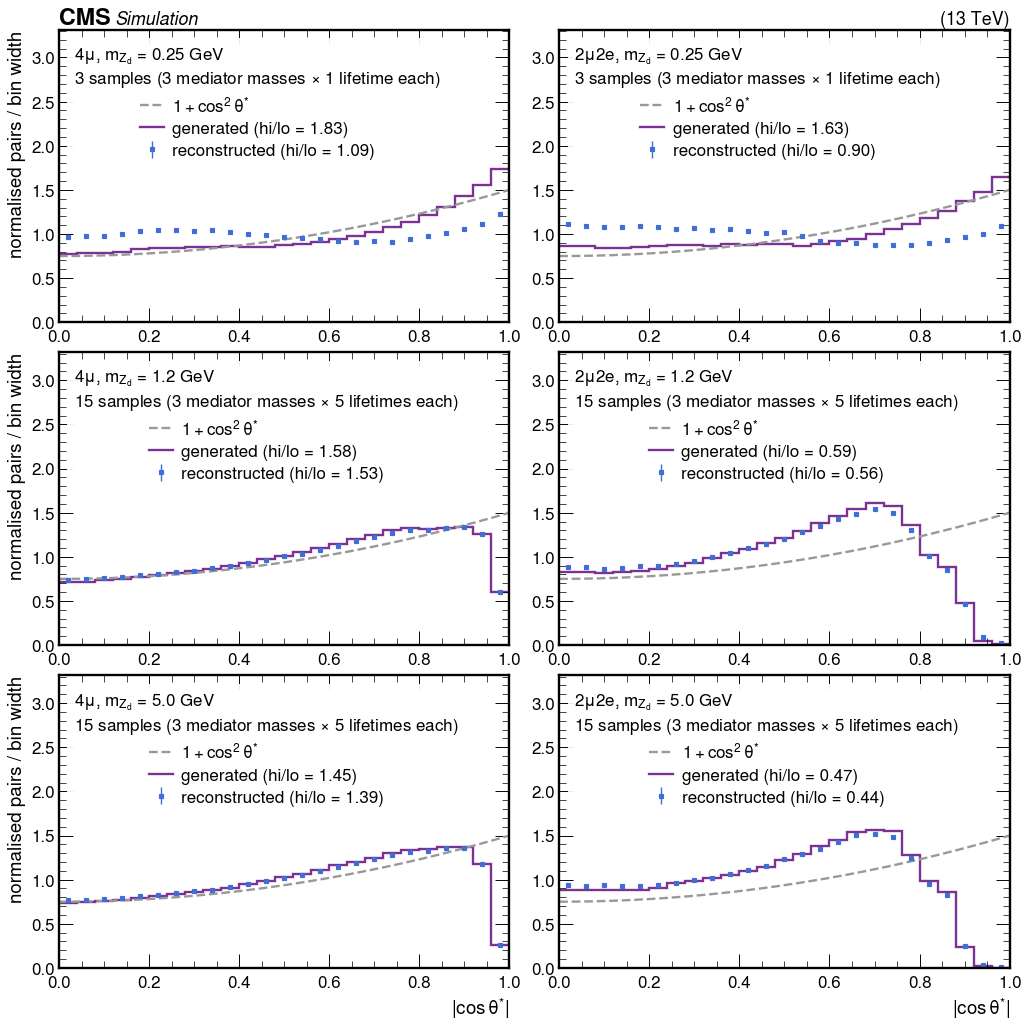

In [4]:
c_gen_reco = lib.fig_gen_vs_reco(m_zd_values=M_ZD_VALUES)

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/b2_ridge_map.pdf
  reconstructed column means against the band, 25 columns with at least 20 pairs:
    median deviation 0.6%, 23 of 25 columns within 4%
    worst column |cos theta*| = 0.98: measured 0.024 against 0.018, +34%


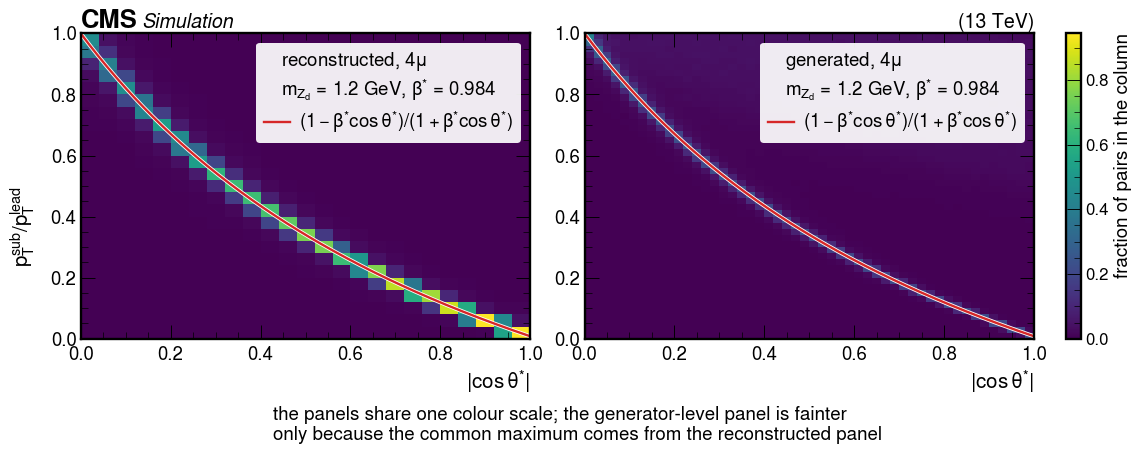

In [5]:
c_ridge = lib.fig_ridge_map(m_zd=M_ZD_REFERENCE)

How to read these figures: the left panels show the reconstructed pairs, the right panels the
generator-level truth, one row per mediator mass, and the dashed curve is the analytic band r =
(1 - beta* cos theta*)/(1 + beta* cos theta*) evaluated at the sample dimuon mass. The
reconstructed pairs track the analytic ridge bin for bin; the printed line under the figure
gives the agreement (median column deviation 0.6 percent, 23 of 25 columns within 4 percent,
the worst column at the sparse |cos(theta*)| = 0.98 edge). What reconstruction does to the
angle depends strongly on the mass. At m_Zd = 1.2 and 5.0 GeV it is nearly transparent: the
hi/lo ratio (density above 0.8 over density below 0.2) moves from 1.58 generated to 1.53
reconstructed at 1.2 GeV in the 4mu channel, and by three to seven percent shifts elsewhere. At
m_Zd = 0.25 GeV it is destructive: the generated distribution is the steepest of the three
masses (hi/lo 1.83 in 4mu, 1.63 in 2mu2e), yet the reconstructed one is flat (1.09 and 0.90).
Near the dimuon threshold beta* is small, the pair-frame direction is dominated by momentum
resolution, and the reconstructed pair mass straddles the threshold itself, so the angle is
unmeasurable there in practice. The overflow of the |cos(theta*)| axis collects two small
pathological populations documented in the caveats (pairs reconstructed below the dimuon
threshold, and near-threshold pairs rounded to just above one in single precision); the in-
range bins are unaffected.

## c. Acceptance

The reconstructed angle in the two signal final states side by side, and where the sub-leading muon
of the pair sits in transverse momentum as a function of the angle.  The dashed lines on the maps
mark the two trigger-relevant thresholds; the top-right panel is the fraction of pairs below each of
them, drawn only where the angle bin holds at least 20 pairs.

The map is drawn on the bin index of the momentum axis, because that axis is variable-binned from
zero and a logarithmic axis would drop its first bin.

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/c1_acceptance.pdf


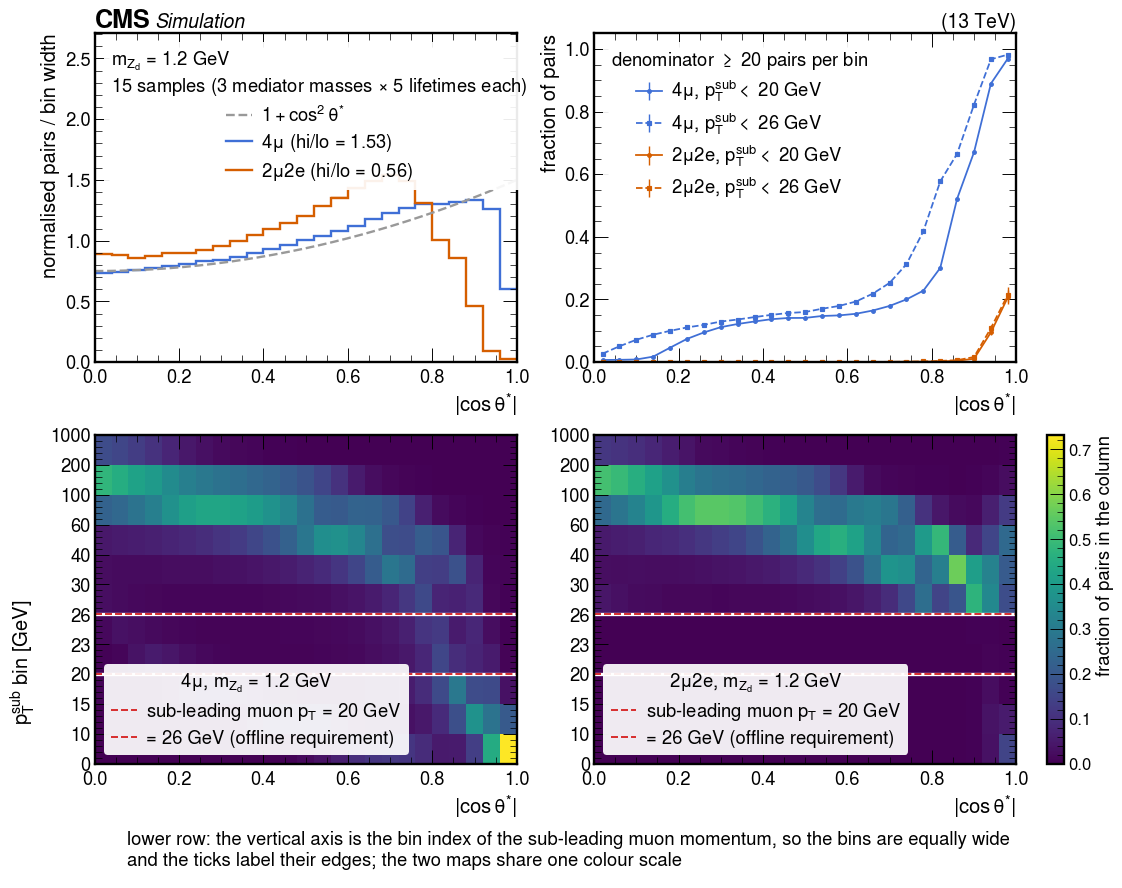

In [6]:
c_acceptance = lib.fig_acceptance(m_zd=M_ZD_REFERENCE)

The reconstructed |cos(theta*)| shape is sculpted by the trigger and muon pT thresholds, and
the sculpting is channel dependent. Large |cos(theta*)| means a hard-soft pair: as
|cos(theta*)| -> 1 the sub-leading muon pT collapses (visible in the maps as the population
crossing below the 20-26 GeV lines). In the 2mu2e channel both level-2 trigger muons (23 or 25
GeV) must come from the single muon lepton jet, and the offline selection then requires two
muons above 26 GeV, so asymmetric pairs fail and the distribution is cut off well before
|cos(theta*)| = 1. In the 4mu channel the two required muons can come from different lepton
jets, and the asymmetric pairs survive even though the fraction of them whose sub-leading muon
falls below the 26 GeV requirement grows to about two thirds by |cos(theta*)| = 0.86. The same
mechanism acts in any selection requiring two muons above 26 GeV from one lepton jet, which is
why the signal shape in the spread-cleaned single-LJ control region below is depleted above
0.8. Consequence: none of the reconstructed shapes here is a polarization measurement; they are
shapes under a fixed selection, compared like for like.

## d. Signal, simulated background and data, region by region

Unit-area shapes so that only the shape is compared: rows are the five regions, columns the
dark-photon mass.  Signal curves sum the three mediator masses with raw-count weights; the
per-mass table below shows the spread that sum hides.
Simulated backgrounds are combined with their cross-section weights before the shape is taken.  The
observed distribution carries asymmetric Poisson error bars.

Everything in a panel is drawn under the same selection as the data in that panel, which is the
comparison this study is built to make.  Panels with no entries are left empty and labelled.

Note on the two validation-region rows: their inverted-displacement requirement can only be met by a
particle-flow muon, so pairs containing displaced-standalone muons are absent there by construction.
The row labels say so, and caveat 2 below spells it out.

  [note] signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 0.25 GeV, absCosTheta: 34 entries over 5 bins, below the 50 needed to draw a shape at all; not drawn


  high-to-low density ratio of every curve drawn (mean density above 0.8 over mean density below 0.2):
    region                                 | series                 |  m_Zd |          hi/lo
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  0.25 |  0.734 +- 0.029
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  0.25 |  0.716 +- 0.022
    1 mu-LJ CR (no cleaning)               | simulated background   |     - |  0.023 +- 0.001
    1 mu-LJ CR (no cleaning)               | data                   |     - |  0.035 +- 0.000
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  1.20 |  1.237 +- 0.009
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  1.20 |  0.644 +- 0.008
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  5.00 |  1.157 +- 0.009
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  5.00 |  0.658 +- 0.008
    1 mu-LJ CR + cosmic veto               | signal 

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/d1_region_shapes_absCosTheta.pdf


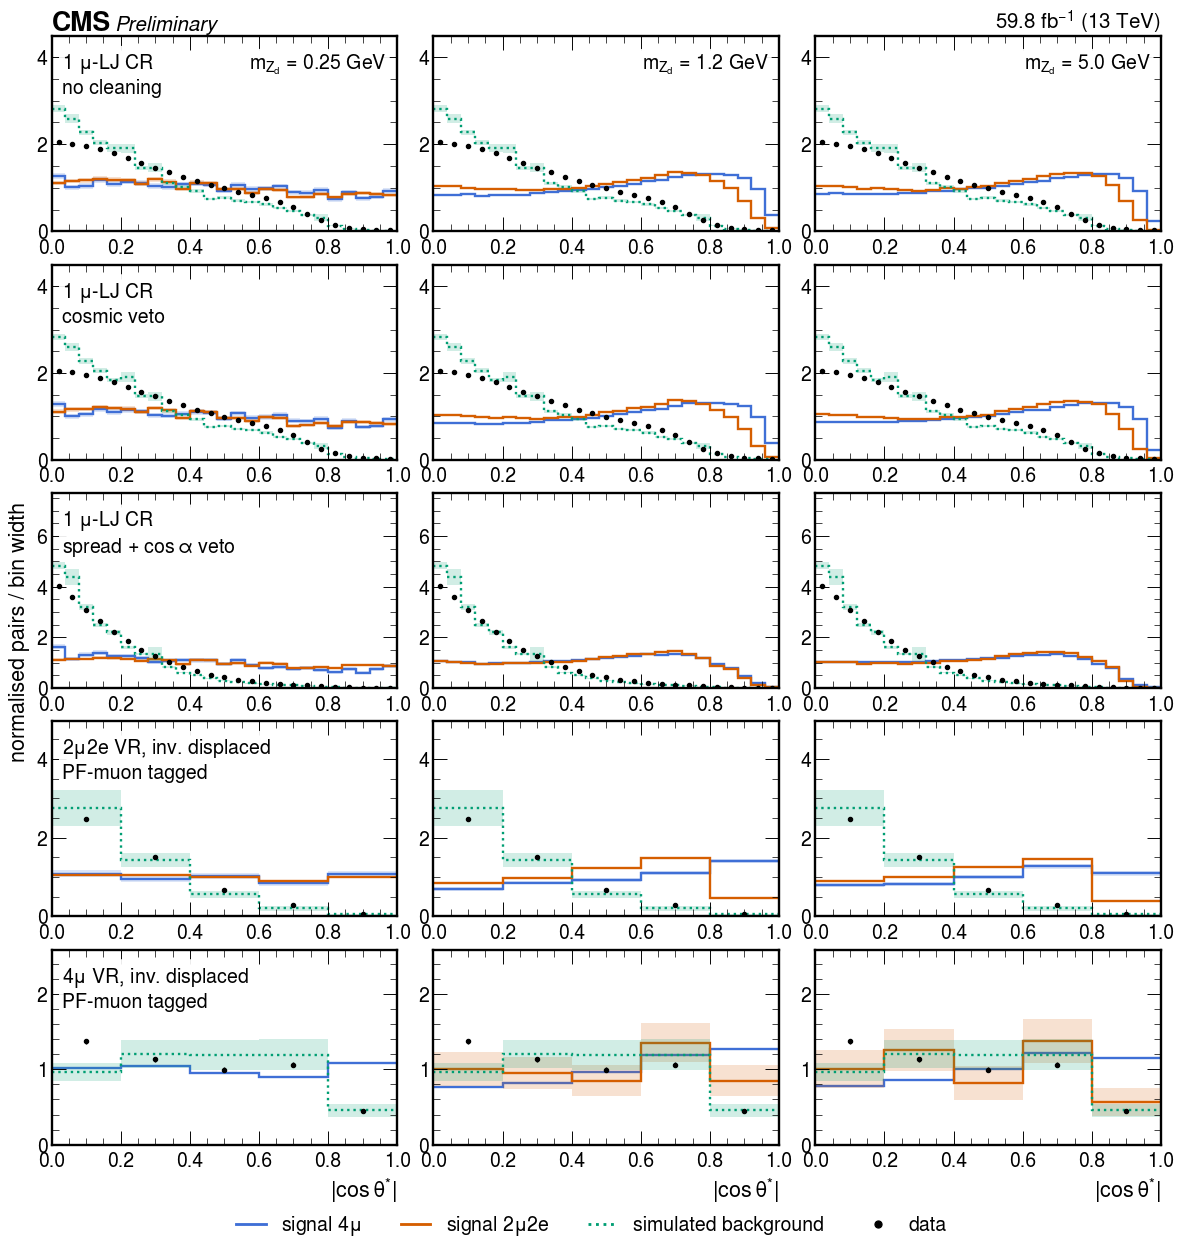

In [7]:
c_shapes_cos = lib.fig_region_shapes("absCosTheta", m_zd_values=M_ZD_VALUES)

  [note] signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 0.25 GeV, ptRatio: 34 entries over 10 bins, below the 50 needed to draw a shape at all; not drawn
  [note] signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 5.0 GeV, ptRatio: 3 of 10 bins hold fewer than 5 effective entries and are not drawn


  high-to-low density ratio of every curve drawn (mean density above 0.8 over mean density below 0.2):
    region                                 | series                 |  m_Zd |          hi/lo
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  0.25 | 14.089 +- 1.451
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  0.25 | 14.225 +- 1.163
    1 mu-LJ CR (no cleaning)               | simulated background   |     - |  5.756 +- 0.200
    1 mu-LJ CR (no cleaning)               | data                   |     - |  4.289 +- 0.007
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  1.20 |  0.263 +- 0.002
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  1.20 |  0.399 +- 0.005
    1 mu-LJ CR (no cleaning)               | signal 4mu             |  5.00 |  0.269 +- 0.002
    1 mu-LJ CR (no cleaning)               | signal 2mu2e           |  5.00 |  0.386 +- 0.005
    1 mu-LJ CR + cosmic veto               | signal 

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/d1_region_shapes_ptRatio.pdf


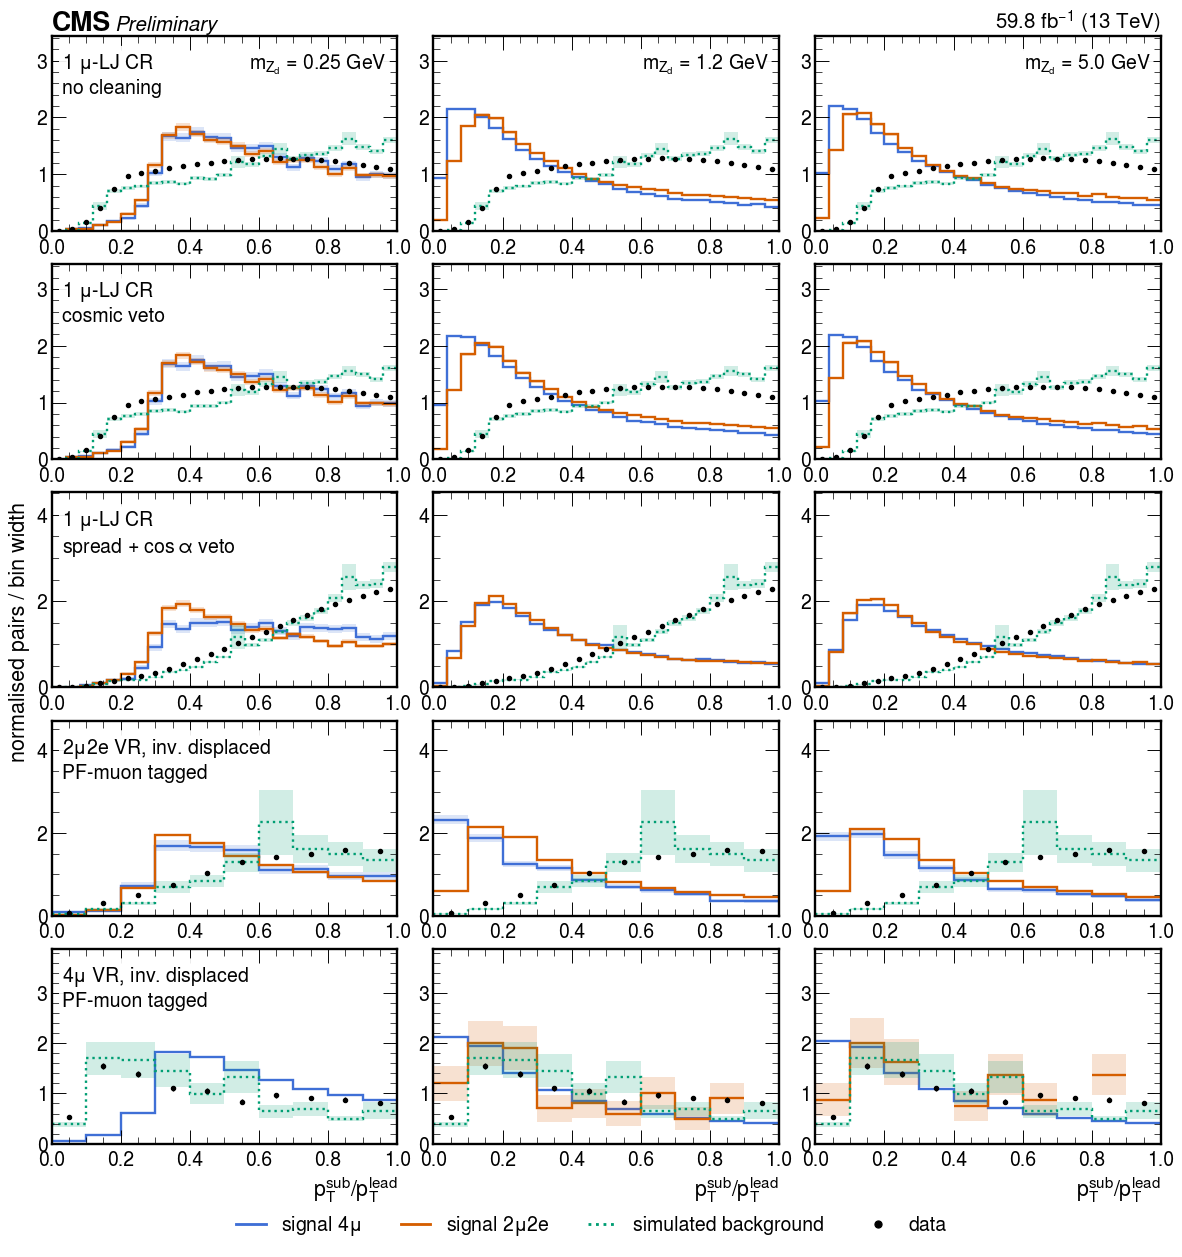

In [8]:
c_shapes_ratio = lib.fig_region_shapes("ptRatio", m_zd_values=M_ZD_VALUES)

How to read this figure: each row is one region, each column one dark-photon mass, every
curve is normalized to unit area, and the question is whether the fake-dominated data shape
differs from the signal shape under the same selection. The signal curves sum the three
bound-state masses m_XX = 100, 500 and 1000 GeV with raw-count weights; the printed table
under the figure gives every curve's hi/lo ratio and the per-mass split, and the spread
across m_XX is large (at m_Zd = 1.2 GeV in this control region the 4mu hi/lo runs from 0.07
at m_XX = 100 to 2.48 at m_XX = 1000, because heavier bound states make harder lepton jets
whose asymmetric pairs survive the thresholds). The data shape falls steeply with
|cos(theta*)| in the single-LJ control regions and in the 2mu2e validation region (hi/lo
0.008 to 0.035) and only mildly in the 4mu validation region (0.33). The signal curves as
drawn give hi/lo 1.24 and 1.16 in 4mu at m_Zd = 1.2 and 5.0 GeV; in 2mu2e they give 0.64
and 0.66, the tail above 0.8 removed by acceptance, with the separation from data living in
the middle of the axis, 0.4 < |cos(theta*)| < 0.8. Three qualifications. First, the
m_Zd = 0.25 GeV column separates from nothing useful (hi/lo 0.73 and 0.72 as drawn): the
generated angle at this mass is the steepest of the three, and the flatness is entirely a
reconstruction effect near the dimuon threshold (section b), so the variable is unusable at
that mass point. Second, in regions that require two 26 GeV muons from the single jet, the
signal tail above 0.8 is removed by acceptance (previous section) and only the mid-axis
separation remains. Third, the weighted background simulation in the validation-region rows
rests on a few hundred effective entries dominated by a handful of high-weight QCD events;
it is shown for completeness, and the data decide.

## e. What the angle correlates with

If the shape of the angle in a control region is to be carried into the signal region, it must not
depend on the quantities that separate the two.  Each panel below takes one companion quantity,
slices the data in it, and overlays the unit-area angular distribution of each slice; a change of
shape between the curves of one panel is a correlation.  The companions are split over two
figures each, four panels apiece, so that every panel is wide enough to read at the width the
figure is placed at.  The profile figures show the same
information as one number per companion bin, the mean angle, with the standard error of the mean and
only where the bin holds at least 20 pairs.

The measurement is made in the uncut single-lepton-jet control region, which is the only region that
contains pairs across the whole range of displacement and both muon types.  The same set is repeated
for signal, where the angle is a property of a real decay.

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e1a_correlation_overlays_data_displacement.pdf
  pairs behind each slice of 2018 data, single muon-lepton-jet control region: isolation and impact parameters:
    mu-LJ isolation  |      < 0.1 |    1,169,495
    mu-LJ isolation  |    0.1-0.3 |    1,906,041
    mu-LJ isolation  |      0.3-1 |    3,830,033
    mu-LJ isolation  |       1-10 |    1,329,597
    min |d_xy| [cm]  |     < 0.02 |    7,021,780
    min |d_xy| [cm]  |   0.02-0.1 |    1,067,648
    min |d_xy| [cm]  |      0.1-1 |       88,770
    min |d_xy| [cm]  |     1-1000 |       64,441
    max |d_xy| [cm]  |     < 0.02 |    4,864,575
    max |d_xy| [cm]  |   0.02-0.1 |    2,241,925
    max |d_xy| [cm]  |      0.1-1 |      564,132
    max |d_xy| [cm]  |     1-1000 |      572,007
    d_xy spread [cm] |      < 0.1 |    6,788,994
    d_xy spread [cm] |      0.1-1 |      825,352
    d_xy spread [cm] |       1-10 |      435,124
    d_xy spread [c

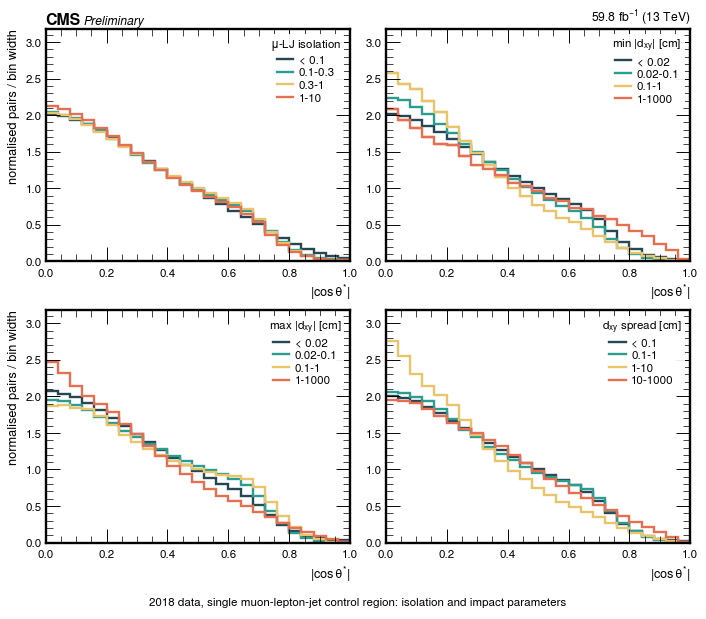

In [9]:
c_corr_data_d = lib.fig_correlation_overlays(
    lib.data_samples(), lib.UNCUT_CR,
    "2018 data, single muon-lepton-jet control region: isolation and impact parameters",
    "e1a_correlation_overlays_data_displacement", is_data=True,
    companions=lib.companion_group("displacement"))

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e1b_correlation_overlays_data_kinematics.pdf
  pairs behind each slice of 2018 data, single muon-lepton-jet control region: kinematics and muon type:
    mu-LJ p_T [GeV]   |       < 50 |    4,107,723
    mu-LJ p_T [GeV]   |     50-100 |    3,616,965
    mu-LJ p_T [GeV]   |    100-200 |      471,886
    mu-LJ p_T [GeV]   |   200-1000 |       45,567
    m_mumu [GeV]      |        < 1 |    1,625,851
    m_mumu [GeV]      |        1-2 |    1,930,079
    m_mumu [GeV]      |        2-6 |    4,109,134
    m_mumu [GeV]      |      6-200 |      577,352
    DSA muons in pair |  0 (PF-PF) |    7,639,850
    DSA muons in pair | 1 (PF-DSA) |      536,349
    DSA muons in pair | 2 (DSA-DSA) |       66,440
    d_z spread [cm]   |      < 0.1 |    6,105,197
    d_z spread [cm]   |      0.1-1 |    1,224,552
    d_z spread [cm]   |       1-10 |      505,638
    d_z spread [cm]   |    10-1000 |      407,085


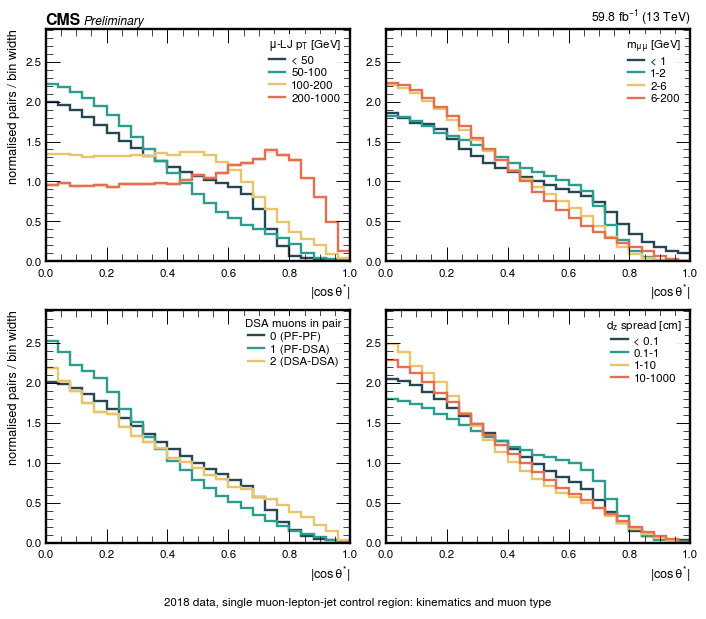

In [10]:
c_corr_data_k = lib.fig_correlation_overlays(
    lib.data_samples(), lib.UNCUT_CR,
    "2018 data, single muon-lepton-jet control region: kinematics and muon type",
    "e1b_correlation_overlays_data_kinematics", is_data=True,
    companions=lib.companion_group("kinematics"))

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e2_correlation_profiles_data.pdf


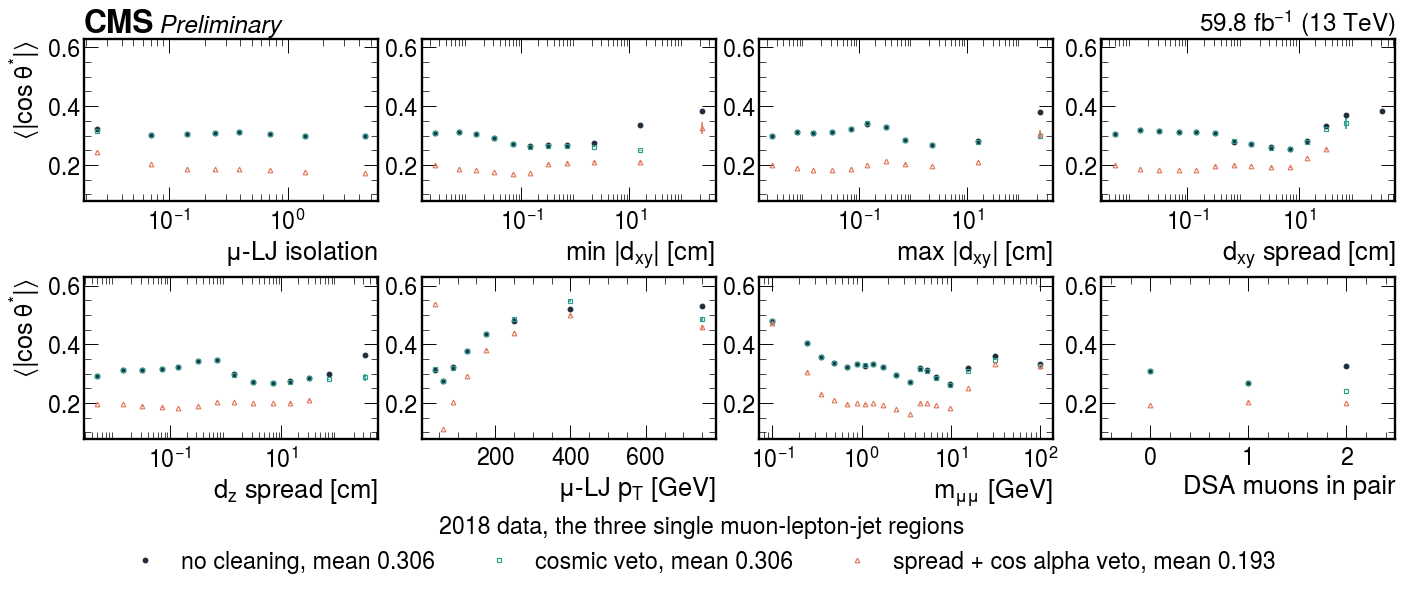

In [11]:
c_prof_data = lib.fig_correlation_profiles(
    lib.data_samples(), lib.UNCUT_CR,
    "2018 data, the three single muon-lepton-jet regions",
    "e2_correlation_profiles_data", is_data=True,
    regions=lib.PROFILE_REGIONS)

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e3a_correlation_overlays_signal_displacement.pdf
  pairs behind each slice of signal 4mu, m_Z_d = 1.2 GeV, four-muon channel: isolation and impact parameters:
    mu-LJ isolation  |      < 0.1 |    2,123,001
    mu-LJ isolation  |    0.1-0.3 |      125,875
    mu-LJ isolation  |      0.3-1 |       18,073
    mu-LJ isolation  |       1-10 |        2,363
    min |d_xy| [cm]  |     < 0.02 |    1,805,674
    min |d_xy| [cm]  |   0.02-0.1 |      263,038
    min |d_xy| [cm]  |      0.1-1 |      167,447
    min |d_xy| [cm]  |     1-1000 |       38,849
    max |d_xy| [cm]  |     < 0.02 |    1,344,663
    max |d_xy| [cm]  |   0.02-0.1 |      401,909
    max |d_xy| [cm]  |      0.1-1 |      293,150
    max |d_xy| [cm]  |     1-1000 |      235,286
    d_xy spread [cm] |      < 0.1 |    1,699,814
    d_xy spread [cm] |      0.1-1 |      322,654
    d_xy spread [cm] |       1-10 |      213,368
    d_xy spread [c

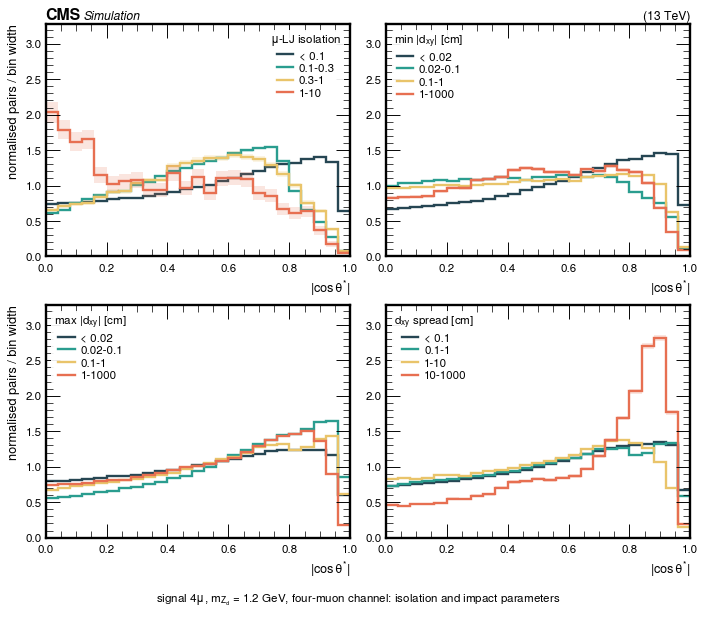

In [12]:
c_corr_sig_d = lib.fig_correlation_overlays(
    lib.signal_samples("4Mu", m_zd=M_ZD_REFERENCE), "4mu",
    f"signal $4\\mu$, $m_{{Z_d}}$ = {M_ZD_REFERENCE} GeV, four-muon channel: "
    "isolation and impact parameters",
    "e3a_correlation_overlays_signal_displacement",
    companions=lib.companion_group("displacement"))

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e3b_correlation_overlays_signal_kinematics.pdf
  pairs behind each slice of signal 4mu, m_Z_d = 1.2 GeV, four-muon channel: kinematics and muon type:
    mu-LJ p_T [GeV]   |       < 50 |      128,986
    mu-LJ p_T [GeV]   |     50-100 |      124,211
    mu-LJ p_T [GeV]   |    100-200 |      455,290
    mu-LJ p_T [GeV]   |   200-1000 |    1,564,532
    m_mumu [GeV]      |        < 1 |      179,315
    m_mumu [GeV]      |        1-2 |    1,830,582
    m_mumu [GeV]      |        2-6 |      206,431
    m_mumu [GeV]      |      6-200 |       57,257
    DSA muons in pair |  0 (PF-PF) |    1,925,172
    DSA muons in pair | 1 (PF-DSA) |      264,196
    DSA muons in pair | 2 (DSA-DSA) |       85,640
    d_z spread [cm]   |      < 0.1 |    1,560,401
    d_z spread [cm]   |      0.1-1 |      342,119
    d_z spread [cm]   |       1-10 |      279,465
    d_z spread [cm]   |    10-1000 |       93,023


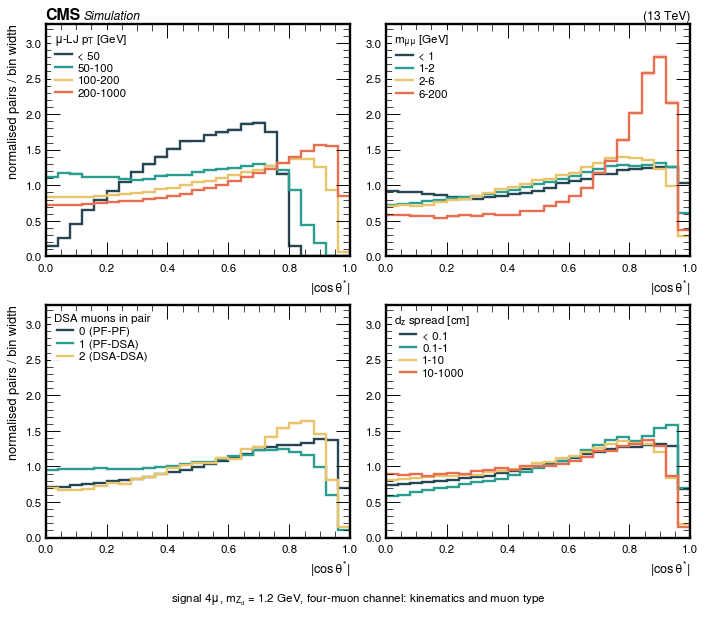

In [13]:
c_corr_sig_k = lib.fig_correlation_overlays(
    lib.signal_samples("4Mu", m_zd=M_ZD_REFERENCE), "4mu",
    f"signal $4\\mu$, $m_{{Z_d}}$ = {M_ZD_REFERENCE} GeV, four-muon channel: "
    "kinematics and muon type",
    "e3b_correlation_overlays_signal_kinematics",
    companions=lib.companion_group("kinematics"))

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/e4_correlation_profiles_signal.pdf


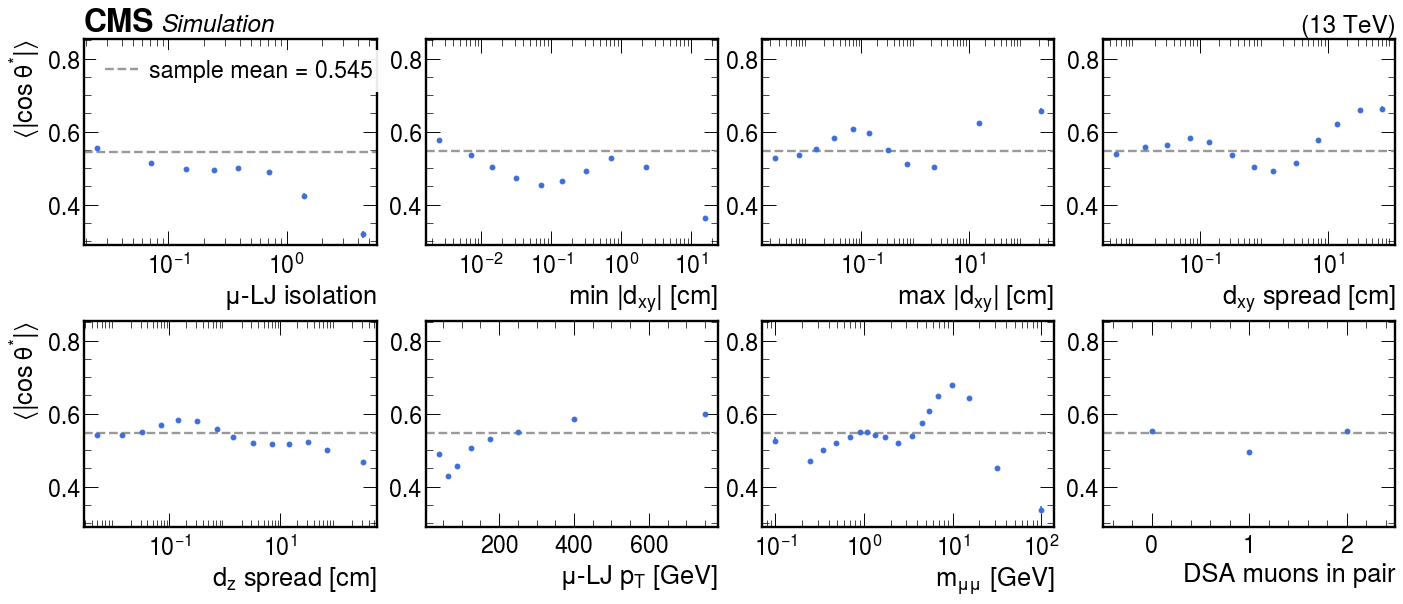

In [14]:
c_prof_sig = lib.fig_correlation_profiles(
    lib.signal_samples("4Mu", m_zd=M_ZD_REFERENCE), "4mu",
    f"signal $4\\mu$, $m_{{Z_d}}$ = {M_ZD_REFERENCE} GeV, four-muon channel",
    "e4_correlation_profiles_signal")

How to read these figures: each panel slices the control-region data in one companion variable;
identical normalized shapes across slices (overlays) and a flat profile of the mean (profiles)
would mean the decay angle carries information independent of that companion. The profile
figure overlays three data regions: the uncut single-LJ control region, the same region with
the cosmic veto, and the same region with the spread and cos-alpha cleaning. Against lepton-jet
pT the mean rises in every region (Spearman rank correlation +0.98, +0.95, +0.31; from 0.31 at
40 GeV to 0.53 at 750 GeV in the uncut region): harder jets keep their asymmetric pairs, the
acceptance mechanism again. Against isolation the dependence is a moderate fall (mean 0.322 to
0.300 uncut; steeper, -0.93 in rank, after the spread cleaning). Against displacement the
answer depends on the cleaning, and that dependence is itself the finding. In the uncut region
the profile of the mean against the smaller |dxy| of the pair dips by about 13 percent below
one centimeter and then rises to 24 percent above its inner value in the outer bins; after the
cosmic veto the same profile falls by 20 percent (rank correlation -0.92, the visible
difference confined to the outermost bins), because the outer displacement bins of the uncut
region are dominated by the cosmic-ray population the veto removes, together with its |dxy| <=
40 cm requirement on the displaced-standalone muons; after the spread and cos-alpha cleaning it
rises again (+63 percent, rank +0.68) on a much smaller residual sample. The size and even the
sign of the displacement dependence change with the cleaning applied, that is, with the
composition of the surviving fakes. The decay angle is therefore not measured to be independent
of displacement, and nothing in this study demonstrates that a fake shape measured in prompt
regions transfers across the displacement axis. Any use of the variable in a background
estimate has to measure that dependence in the estimate's own regions.

## f. What a straight cut on the angle would buy

Solid curves are the fraction of signal pairs a threshold keeps, measured in the signal channel of
each final state; dashed curves are the fraction of control-region pairs it rejects.  Bands are
Clopper-Pearson intervals.  Both directions of the cut are shown.

Signal efficiency and fake rejection are measured under different selections -- signal in its own
channel, fakes in the data control region -- so the two curves in a panel answer "what would this
threshold do here", not "what would it do to the same sample".

The signal curves sum the three mediator masses with raw-count weights; the per-mass table below
shows the spread that sum hides.  The figure draws only the two single-lepton-jet control regions
as fakes, so the two validation regions are tabulated under it as well.

  wrote /uscms_data/d3/murtazas/SIDM-wt-muljangle/sidm/studies/mulj_decay_angle/figures/f1_cut_scan.pdf


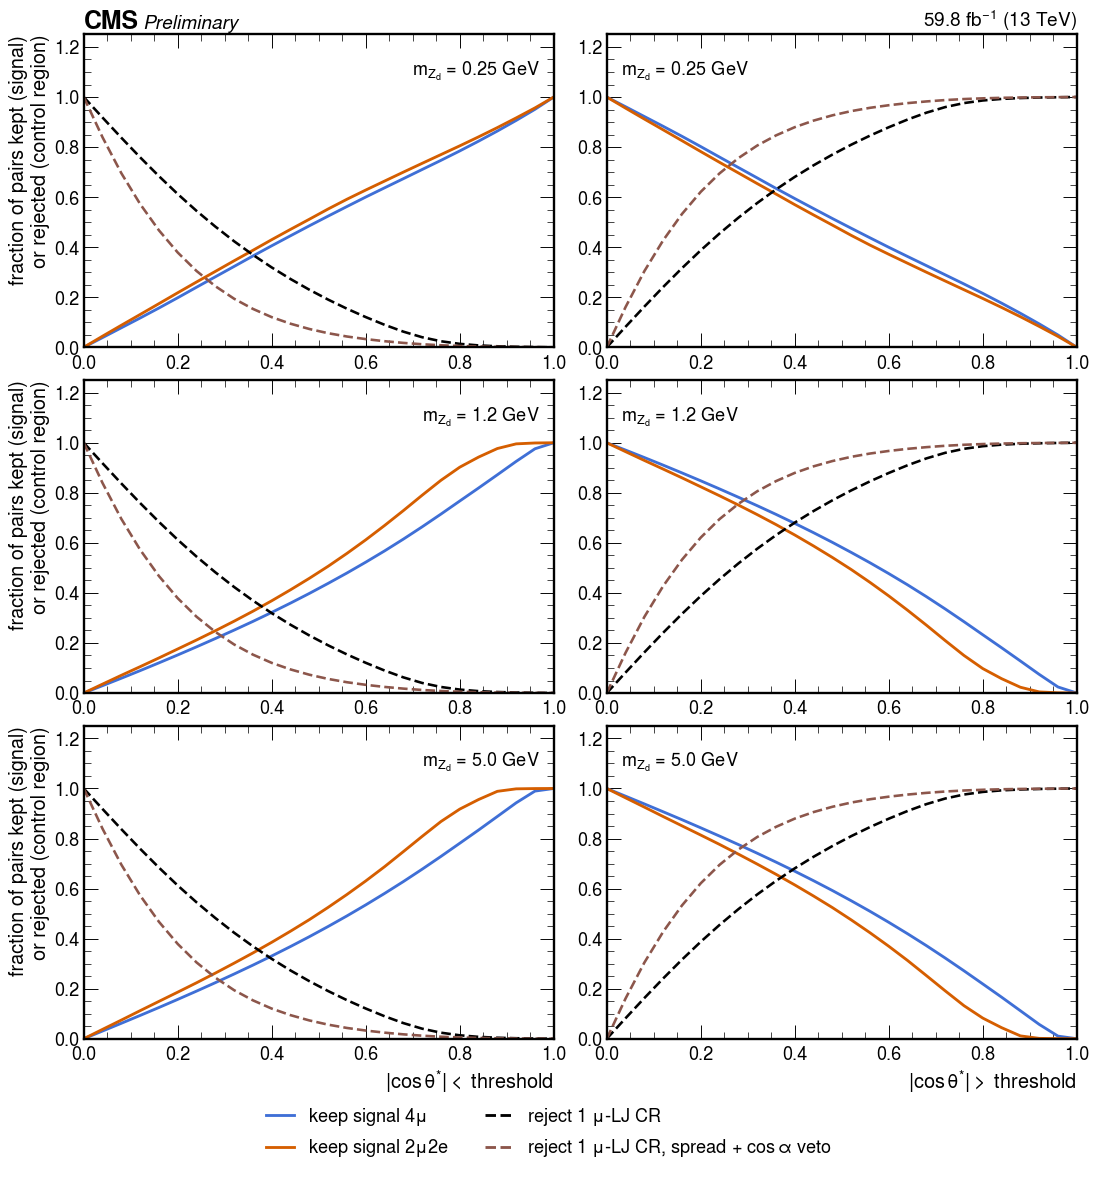

In [15]:
scan = lib.cut_scan(m_zd_values=M_ZD_VALUES)
c_scan = lib.fig_cut_scan(scan, m_zd_values=M_ZD_VALUES)

In [16]:
_ = lib.efficiency_by_mediator_mass(m_zd_values=M_ZD_VALUES)
print()
_ = lib.validation_region_rejection()

  signal pairs kept by |cos theta*| > threshold, one row per mediator mass:
    channel |  m_Zd |   m_XX |     pairs |    0.20 |    0.40 |    0.60 |    0.80
    ----------------------------------------------------------------------------
    4mu     |  0.25 |    100 |    79,982 |   0.872 |   0.685 |   0.469 |   0.236
    4mu     |  0.25 |    500 |   459,948 |   0.787 |   0.573 |   0.380 |   0.200
    4mu     |  0.25 |   1000 |   273,877 |   0.807 |   0.604 |   0.412 |   0.235
    4mu     |  1.20 |    100 |   200,107 |   0.857 |   0.627 |   0.330 |   0.020
    4mu     |  1.20 |    500 | 1,224,706 |   0.838 |   0.665 |   0.466 |   0.225
    4mu     |  1.20 |   1000 |   848,041 |   0.860 |   0.708 |   0.528 |   0.294
    4mu     |  5.00 |    100 |   135,728 |   0.845 |   0.609 |   0.308 |   0.019
    4mu     |  5.00 |    500 | 1,155,250 |   0.836 |   0.660 |   0.456 |   0.209
    4mu     |  5.00 |   1000 |   901,842 |   0.851 |   0.690 |   0.500 |   0.262
    2mu2e   |  0.25 |    100 |   

In [17]:
_ = lib.cut_scan_table(scan, direction="below")
print()
_ = lib.cut_scan_table(scan, direction="above")

  |cos theta*| < threshold
    m_Zd | curve                                  |   cut |               kept | rejected |    pairs
  --------------------------------------------------------------------------------------------------
    0.25 | signal 4mu                             |  0.20 | 0.198 -0.000/+0.000 |    0.802 |   813807
    0.25 | signal 4mu                             |  0.40 | 0.406 -0.001/+0.001 |    0.594 |   813807
    0.25 | signal 4mu                             |  0.60 | 0.600 -0.001/+0.001 |    0.400 |   813807
    0.25 | signal 4mu                             |  0.80 | 0.785 -0.000/+0.000 |    0.215 |   813807
    0.25 | signal 4mu                             |  0.88 | 0.864 -0.000/+0.000 |    0.136 |   813807
    0.25 | signal 2mu2e                           |  0.20 | 0.218 -0.001/+0.001 |    0.782 |   157638
    0.25 | signal 2mu2e                           |  0.40 | 0.430 -0.001/+0.001 |    0.570 |   157638
    0.25 | signal 2mu2e                           |  0.60

How to read this figure: solid curves are the fraction of signal pairs kept by a cut at the
threshold on the x axis, dashed curves the fraction of control-region data pairs rejected; both
directions of the cut are shown because the informative side differs by channel. The curves sum
the three bound-state masses; the printed tables under the figure give the per-mass
efficiencies and the validation-region rejections, and the mass dependence is decisive. A cut
keeping |cos(theta*)| > 0.4 rejects 79.6 percent of the data pairs in the 2mu2e inverted-
displacement validation region and 50.0 percent in the 4mu one (printed table; the figure draws
the two single-LJ control regions, where the same cut rejects 68 and 88 percent). The same cut
keeps, in the 2mu2e channel, 55 to 56 percent of signal pairs at m_XX = 500 GeV and 70 to 74
percent at 1000 GeV for the two heavier dark-photon masses, but only 5 percent at m_XX = 100
GeV (and 12 percent at m_Zd = 0.25 GeV there): the lightest bound state makes the softest
lepton jets, exactly the ones whose asymmetric pairs the trigger and the 26 GeV requirement
already remove. In the 4mu channel the efficiency is flatter, 57 to 71 percent across the grid.
These are per-lepton-jet numbers in fake-enriched displaced-vetoed regions, not per-event
signal-region predictions; in the 4mu channel a per-jet cut applies to both muon lepton jets of
an event, so the event-level signal cost is roughly the square of the per-jet efficiency. They
size the handle; they do not certify it.

## g. Caveats

These apply to every reading of the figures above.

1. **The reconstructed angle is shaped by the selection.** The high-to-low population ratio printed
   in the legends of the first figures is not the value an unsculpted 1 + cos^2 decay would give, and
   the two-muon-two-electron final state loses the region near an absolute cosine of one, because
   both muons that fire the dimuon trigger have to come from the one muon lepton jet and the
   sub-leading muon of a wide-angle pair falls below the trigger threshold.  The generator-level
   distribution in the same channel shows the same shape, which is how the sculpting is identified as
   acceptance rather than physics.  This study compares signal and fake shapes under an identical
   selection; it is not a measurement of the decay's angular distribution, which would require the
   efficiency to be corrected for.

2. **The inverted-displacement validation regions contain no displaced-standalone muons.** The
   vector builder sets the pixel-hit count of a displaced-standalone track to zero, so the inverted
   displacement requirement can only be satisfied by a particle-flow muon with more than two pixel
   hits.  The split by number of displaced-standalone muons in the pair is strongly biased towards
   zero in those regions relative to the signal region.  Pairs containing displaced-standalone muons
   are therefore studied in the uncut single-lepton-jet control region only, and any statement about
   them must be made there.

3. **Impact parameters do not all share a reference.** The angle helper uses primary-vertex
   referenced transverse and longitudinal impact parameters for both muon types.  The lepton-jet
   spread quantities used by the cleaning cuts, which are kept exactly as the cuts define them, mix
   primary-vertex referenced particle-flow values with beamspot referenced displaced-standalone
   values; for a mixed pair the transverse spread is close to the displaced-standalone muon's own
   impact parameter rather than a separation between two vertices.  Do not describe it as a vertex
   separation, and slice by the number of displaced-standalone muons where the distinction matters.

4. **Yields will not match other checkouts exactly.** Other working copies of these regions apply a
   tighter displaced-standalone cross-cleaning and an eta-phi veto that is not applied here.

5. **Histograms are raw counts; cutflows are not.** The campaign ran with unweighted histograms, so
   nothing in the histograms carries a cross-section or generator weight, while the cutflows in the
   same files are luminosity times cross-section scaled.  The two must never be combined.  A
   normalised simulation prediction needs luminosity times cross section divided by the number of
   *generated* events per sample; the sum of weights stored in the metadata counts events that
   survived the skim, and the signal skim keeps only about a tenth of what was generated, so the
   generated count from the file census has to be substituted before any yield is quoted.  Shapes
   are unaffected, because the factor cancels in a unit-area normalisation.

6. **Signal-region channels evaluate their event cuts on unfiltered lepton jets**, so an event whose
   lepton jets are all prompt can still pass a signal-region channel with no muon lepton jets left in
   it.  The orthogonality between the validation and signal regions holds at the level of histogram
   entries, not events.

7. **Two axes merge things that are not the same.** The lepton-jet count in the collection counts
   unfiltered lepton jets, that is, the event multiplicity.  Isolation fills a missing value with
   zero, so "no matched jet" and "isolation exactly zero" land in the same bin and in the first
   isolation slice.

8. **One warning to watch for in the campaign logs.** "Unable to apply event cuts to evt_weights.
   Skipping." was seen once per validation-region channel on data before a duplicate muon-momentum
   line was removed from the selection.  If it reappears, the simulation cutflows should not be
   trusted until it is understood.
9. **Both observables are bounded by one, and both overflow anyway.** An absolute cosine cannot
   exceed one and the sub-leading momentum cannot exceed the leading one, yet the overflow bin of
   each histogram holds entries: 333 pairs of the 8.2 million in the uncut control region, four
   parts in a hundred thousand, and one pair for the momentum ratio.  In simulation the rate is
   larger and mass dependent, reaching five parts in a hundred at m_Zd = 0.25 GeV.  Every one of
   these pairs has a reconstructed dimuon mass either below twice the muon mass, where the rest
   frame of the pair is not defined, or just above it, where the boosted muon is within single
   precision of parallel to the pair and the cosine rounds above one.  Three quarters sit below
   threshold and the remainder within a few hundred MeV of it; none is above 0.8 GeV.  The
   in-range bins are unaffected, and every figure and number here is built from them alone, but
   the m_Zd = 0.25 GeV point sits closest to this boundary and its shape should be read with that
   in mind.

## h. Verdict

The decay angle of the muon pair separates genuine from fake muon lepton jets, and the
separation grows with both the dark-photon mass and the bound-state mass. Fakes in data
fall steeply in |cos(theta*)| in every region examined except the 4mu validation region
(density ratio hi/lo 0.008 to 0.33), while the m_Zd = 1.2 and 5.0 GeV signals are flat to
rising, with the separation concentrated at |cos(theta*)| > 0.4. The handle is real but
narrower than a single number suggests. In the 2mu2e channel a |cos(theta*)| > 0.4
requirement on the muon lepton jet keeps 55 to 74 percent of signal pairs at
m_XX = 500-1000 GeV while removing about 80 percent of validation-region fakes (from the
validation-region shapes, printed under the cut scan), but it keeps only 5 percent at
m_XX = 100 GeV, so it cannot be applied uniformly across the signal grid. In the 4mu
channel the per-jet numbers are 57 to 71 percent kept for 50 percent rejected, and a
per-jet cut acts on both lepton jets of an event, squaring the signal cost. At
m_Zd = 0.25 GeV the variable carries no usable information: the generated distribution is
the steepest of the three masses, and reconstruction near the dimuon threshold flattens it
completely.

On correlation: the decay angle rises strongly with lepton-jet pT in every region, so a cut
would sculpt pT-correlated spectra, including the dijet mass of the 4mu windowed search.
Its dependence on displacement changes size and sign with the cleaning applied (flat with
rising tail uncut, falling after the cosmic veto, rising after the spread cleaning), which
means the fake composition, not the geometry, sets the shape; this study does not establish
that a fake shape measured in prompt regions transfers to the displaced signal regions.

Recommendation: treat |cos(theta*)| as a candidate purity handle and cross-check for the
2mu2e channel at m_XX of a few hundred GeV and above, and as a shape variable worth
monitoring in the 4mu channel; not as a drop-in axis or cut for the background estimate.
Before any use in the estimate itself it needs the displacement dependence measured in the
estimate's own regions, a closure test against the mass axis of the affected search, and
the per-mass acceptance map of this study repeated on the population that matters there.
Two structural caveats stand: the validation regions contain essentially no
displaced-standalone-muon pairs by construction, so the fake shape for those is measured
only in the single-LJ control regions, and the background simulation is statistically too
weak to arbitrate any of this, so the data control regions carry the conclusions.

## Run record

Everything the run could not draw, and why.  On a complete set of campaign inputs this list should
be short; on a reduced input set it records which panels were left empty.

In [18]:
messages = lib.notes()
print(f"{len(messages)} note(s) recorded during this run")
for message in messages:
    print(" -", message)

3 note(s) recorded during this run
 - signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 0.25 GeV, absCosTheta: 34 entries over 5 bins, below the 50 needed to draw a shape at all; not drawn
 - signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 0.25 GeV, ptRatio: 34 entries over 10 bins, below the 50 needed to draw a shape at all; not drawn
 - signal 2mu2e in 4mu inverted-displacement VR, m_Zd = 5.0 GeV, ptRatio: 3 of 10 bins hold fewer than 5 effective entries and are not drawn
